# TensorFlow Tokenization and Word2Vec Pipeline for PII

This notebook implements a TensorFlow-first tokenization and Word2Vec-style embedding workflow for PII-related text using the dataset `syvai/pii-dataset-eng`.

**Dataset**: Hugging Face `syvai/pii-dataset-eng`  
**Goal**: Build and validate a working tokenization + embedding pipeline consistent with project constraints

**Workflow Phases**:
<!-- - 0: Environment bootstrap before kernel initialization -->
- 1: Imports and reproducibility
- 2: Data ingestion and structural validation
- 3: Domain filtering and corpus preparation
- 4: TensorFlow tokenization pipeline
- 5: Skip-gram training with negative sampling
- 6: Embedding inspection and diagnostics
- 7: Timing and practical constraints
- 8: TensorFlow vs Gensim comparative notes (analysis only)

---

<!-- # Phase 0: Environment Bootstrap (Before Kernel Initialization)

Run these commands in a terminal before selecting the notebook kernel:

```bash
conda create -n pii-word2vec-tf python=3.11 -y
conda activate pii-word2vec-tf
python -m pip install --upgrade pip
python -m pip install datasets tensorflow numpy pandas matplotlib scikit-learn charset-normalizer chardet ipywidgets widgetsnbextension jupyterlab_widgets
python -m ipykernel install --user --name pii-word2vec-tf --display-name "Python (pii-word2vec-tf)"
```

After this, select **Python (pii-word2vec-tf)** as your kernel and continue with the notebook. The import cell below includes a fail-fast guard that will stop immediately with a clear message if TensorFlow is missing in the active kernel. -->

# Phase 1: Imports and Reproducibility(seed=42)

## Quick Tuning Guide (What we can tweak)

The constants below control data scope, tokenizer behavior, and embedding training cost/quality trade-offs.

- `SEED` (reproducibility): keeps sampling/shuffling stable across runs.
- `target_labels` (task scope): chooses which PII classes the model will focus on.
- `MAX_DOCS` (dataset size cap): more data can improve quality but increases runtime/memory.
- `VOCAB_SIZE` (token vocabulary cap): larger values capture more rare words but increase model size.
- `SEQUENCE_LENGTH` (max tokens per text): larger values keep more context but increase compute and truncation risk shifts.
- `WINDOW_SIZE` (Skip-gram context radius): larger window captures broader context, smaller window captures local context.
- `NEGATIVE_SAMPLES` (Skip-gram negatives per positive): higher values can improve embedding quality but slow training.
- `EMBEDDING_DIM` (vector size): larger vectors can represent richer semantics but require more data/compute.
- `BATCH_SIZE` (training throughput): larger batches are faster on strong hardware, smaller batches are lighter on memory.
- `EPOCHS` (number of passes): more epochs can improve fit until overfitting or diminishing returns.

In [ ]:
# Centralized parameter configuration for reproducible tuning
SEED = 42

# Task scope
TARGET_LABELS = {'DATE', 'FULL_NAME', 'EMAIL', 'USERNAME', 'STREET_ADDRESS'}
MAX_DOCS = 30000

# Preprocessing decisions overview
# Equivalent baseline logic:
## out = text.lower()
## out = re.sub(r'[^a-z0-9\s]', ' ', out)
## out = re.sub(r'\s+', ' ', out).strip()
PREPROCESS_TO_LOWER = True
PREPROCESS_KEEP_PATTERN = r'[^a-z0-9\s]'
PREPROCESS_WHITESPACE_PATTERN = r'\s+'
PREPROCESS_REPLACE_CHAR = ' '
PREPROCESS_STRIP_WHITESPACE = True

# Tokenization settings
VOCAB_SIZE = 20000
SEQUENCE_LENGTH = 256
VOCAB_ADAPT_BATCH_SIZE = 512

# Skip-gram settings
WINDOW_SIZE = 2
NEGATIVE_SAMPLES = 1.0

# Training settings
BATCH_SIZE = 1024
EMBEDDING_DIM = 128
EPOCHS = 3
SHUFFLE_BUFFER_CAP = 200000

# Embedding diagnostics
PROBE_WORDS = ['date', 'name', 'email', 'username', 'street']
NEIGHBOR_TOP_K = 8

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf 

from datasets import load_dataset
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import make_sampling_table, skipgrams

# Phase 2: Data Ingestion and Structural Validation

In [43]:
dataset = load_dataset('syvai/pii-dataset-eng')
dataset

DatasetDict({
    train: Dataset({
        features: ['source_text', 'privacy'],
        num_rows: 266150
    })
})

In [44]:
for split_name in dataset.keys():
    print(f"{split_name}: {len(dataset[split_name])} rows")

sample = dataset['train'][0]
print('Columns:', list(sample.keys()))
print('Sample source_text (first 200 chars):', sample['source_text'][:200])
print('Sample privacy entries (first 3):', sample['privacy'][:3])

train: 266150 rows
Columns: ['source_text', 'privacy']
Sample source_text (first 200 chars): <p>My child faozzsd379223 (DOB: May/58) will undergo treatment with Dr. faozzsd379223, office at Hill Road. Our ZIP code is 28170-6392. Consult policy M.UE.227995. Contact number: 0070.606.322.6244. H
Sample privacy entries (first 3): [{'label': 'USERNAME', 'value': 'faozzsd379223'}, {'label': 'DATE_OF_BIRTH', 'value': 'May/58'}, {'label': 'STREET', 'value': 'Hill Road'}]


# Phase 2.5: Exploratory Data Analysis (EDA)

This section profiles dataset composition, label distribution, missingness, text-length behavior, and subset effects before tokenization and embedding.

EDA goals:
- quantify dataset structure and potential data quality issues
- measure class skew and long-tail behavior
- define and validate the domain-specific target subset
- document distributional effects introduced by preprocessing choices

In [45]:
# Combine all splits for descriptive EDA while keeping training workflow unchanged.
split_sizes = {split_name: len(dataset[split_name]) for split_name in dataset.keys()}
df_splits = pd.DataFrame({'split': list(split_sizes.keys()), 'rows': list(split_sizes.values())})

all_rows = []
for split_name in dataset.keys():
    for row in dataset[split_name]:
        all_rows.append({
            'split': split_name,
            'source_text': row.get('source_text'),
            'privacy': row.get('privacy')
        })

eda_df = pd.DataFrame(all_rows)

eda_df['source_text_missing'] = eda_df['source_text'].isna() | (eda_df['source_text'].astype(str).str.strip() == '')
eda_df['privacy_missing'] = eda_df['privacy'].isna()
eda_df['privacy_count'] = eda_df['privacy'].apply(lambda x: len(x) if isinstance(x, list) else 0)
eda_df['empty_privacy_list'] = eda_df['privacy_count'] == 0

print('Rows per split:')
print(df_splits)
print('\nTotal rows (all splits):', len(eda_df))
print('Missing/empty source_text rows:', int(eda_df['source_text_missing'].sum()))
print('Missing privacy rows:', int(eda_df['privacy_missing'].sum()))
print('Rows with empty privacy list:', int(eda_df['empty_privacy_list'].sum()))
print('Entities per document summary:')
print(eda_df['privacy_count'].describe().round(2))

Rows per split:
   split    rows
0  train  266150

Total rows (all splits): 266150
Missing/empty source_text rows: 0
Missing privacy rows: 0
Rows with empty privacy list: 0
Entities per document summary:
count    266150.00
mean          2.25
std           2.15
min           1.00
25%           1.00
50%           2.00
75%           2.00
max          40.00
Name: privacy_count, dtype: float64


Total extracted entities: 598359
Distinct labels: 36

Top 15 labels by frequency:


,count
DATE,63765
FULL_NAME,62799
FIRST_NAME,53564
EMAIL,39868
LAST_NAME,36916
USERNAME,34142
STREET_ADDRESS,33292
CITY,32139
COMPANY,31253
PHONE_NUMBER,30303


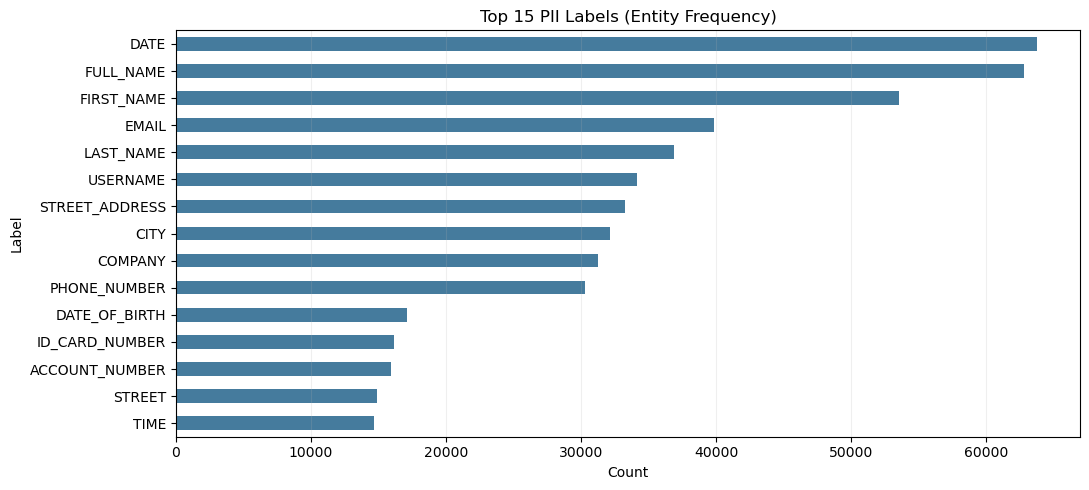

Share of entities covered by top 15 labels: 0.830


In [46]:
# Flatten privacy labels for frequency analysis.
all_labels = []
for privacy_list in eda_df['privacy']:
    if isinstance(privacy_list, list):
        for item in privacy_list:
            if isinstance(item, dict) and 'label' in item:
                all_labels.append(item['label'])

label_counts = pd.Series(all_labels, dtype='object').value_counts()
total_entities = int(label_counts.sum())
num_distinct_labels = int(label_counts.shape[0])

print('Total extracted entities:', total_entities)
print('Distinct labels:', num_distinct_labels)
print('\nTop 15 labels by frequency:')
display(label_counts.head(15).to_frame('count'))

plt.figure(figsize=(11, 5))
label_counts.head(15).sort_values(ascending=True).plot(kind='barh', color='#457b9d')
plt.title('Top 15 PII Labels (Entity Frequency)')
plt.xlabel('Count')
plt.ylabel('Label')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

top15_share = float(label_counts.head(15).sum() / max(total_entities, 1))
print(f'Share of entities covered by top 15 labels: {top15_share:.3f}')

Character length summary (all rows):
count    266150.00
mean        359.85
std         499.93
min           4.00
50%         161.00
90%        1215.00
95%        1592.00
99%        2239.00
max        7859.00
Name: char_length, dtype: float64

Whitespace token count summary (all rows):
count    266150.00
mean         46.88
std          71.24
min           1.00
50%          20.00
90%         161.00
95%         231.00
99%         327.00
max         494.00
Name: whitespace_token_count, dtype: float64


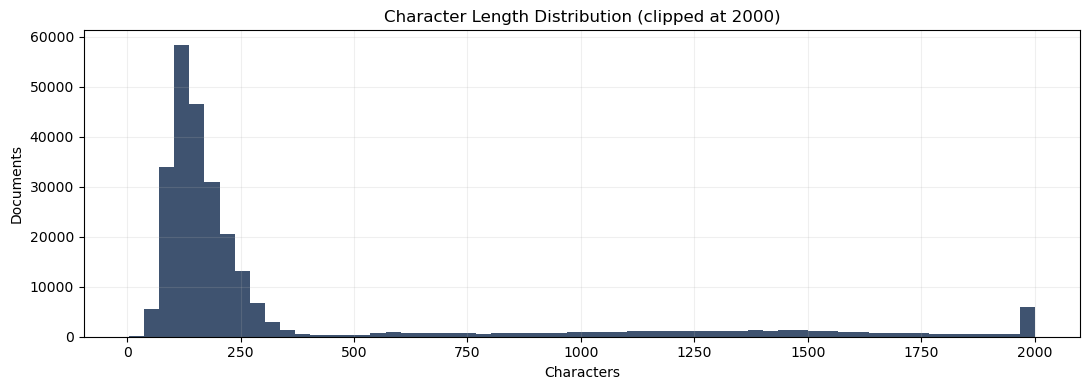

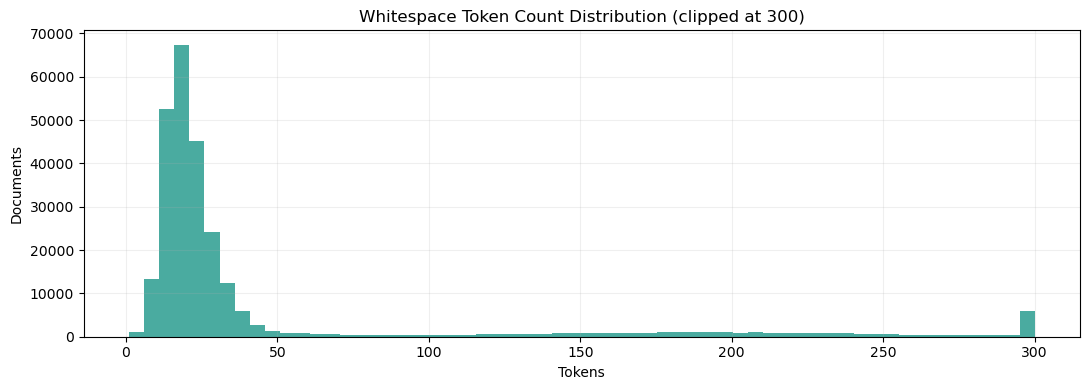

In [47]:
# Raw text-length and token-count distribution before modeling.
eda_df['char_length'] = eda_df['source_text'].astype(str).str.len()
eda_df['whitespace_token_count'] = eda_df['source_text'].astype(str).str.split().apply(len)

print('Character length summary (all rows):')
print(eda_df['char_length'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))
print('\nWhitespace token count summary (all rows):')
print(eda_df['whitespace_token_count'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))

plt.figure(figsize=(11, 4))
plt.hist(eda_df['char_length'].clip(upper=2000), bins=60, color='#1d3557', alpha=0.85)
plt.title('Character Length Distribution (clipped at 2000)')
plt.xlabel('Characters')
plt.ylabel('Documents')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
plt.hist(eda_df['whitespace_token_count'].clip(upper=300), bins=60, color='#2a9d8f', alpha=0.85)
plt.title('Whitespace Token Count Distribution (clipped at 300)')
plt.xlabel('Tokens')
plt.ylabel('Documents')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Phase 3: Domain Filtering and Corpus Preparation

Target labels used in this notebook: `DATE`, `FULL_NAME`, `EMAIL`, `USERNAME`, `STREET_ADDRESS`.

In [ ]:
# Core task-scope hyperparameter: choose which PII classes are considered positive targets.
# Expanding this set makes the task broader/harder and changes label balance.
target_labels = TARGET_LABELS

def labels_in_entry(privacy_list):
    # Extract all labels from one annotation list to preserve full label context for analysis.
    labels = []
    for item in privacy_list:
        if isinstance(item, dict) and 'label' in item:
            labels.append(item['label'])
    return labels

def labels_in_target_set(privacy_list):
    # Keep only labels that belong to the current project scope.
    labels = labels_in_entry(privacy_list)
    return [lbl for lbl in labels if lbl in target_labels]

raw_train = dataset['train']

records = []
for row in raw_train:
    labels_all = labels_in_entry(row['privacy'])
    labels_target = [lbl for lbl in labels_all if lbl in target_labels]
    records.append({
        'source_text': row['source_text'],
        'labels_all': labels_all,
        'labels_target': labels_target,
        'has_target_label': len(labels_target) > 0
    })

df = pd.DataFrame(records)
print(df[['labels_all', 'labels_target', 'has_target_label']].head(3))
print('Total rows (train split):', len(df))
print('Rows with target labels:', int(df['has_target_label'].sum()))

                                          labels_all      labels_target  \
0  [USERNAME, DATE_OF_BIRTH, STREET, ZIPCODE, PHO...  [USERNAME, EMAIL]   
1             [USERNAME, DATE_OF_BIRTH, CITY, EMAIL]  [USERNAME, EMAIL]   
2  [USERNAME, BUILDING_NUMBER, CITY, DATE_OF_BIRT...  [USERNAME, EMAIL]   

   has_target_label  
0              True  
1              True  
2              True  
Total rows (train split): 266150
Rows with target labels: 104856


In [ ]:
filtered_df = df[df['has_target_label']].copy()

# Dataset-size control for faster experimentation and fair run-to-run comparison.
# Increase MAX_DOCS for potentially better coverage; reduce it for quicker iteration.
if len(filtered_df) > MAX_DOCS:
    filtered_df = filtered_df.sample(n=MAX_DOCS, random_state=SEED).reset_index(drop=True)

corpus_texts = filtered_df['source_text'].astype(str).tolist()
subset_char_lengths = pd.Series([len(t) for t in corpus_texts])
subset_token_lengths = pd.Series([len(t.split()) for t in corpus_texts])

target_entity_counts = pd.Series(
    [label for labels in filtered_df['labels_target'] for label in labels],
    dtype='object'
).value_counts()

print('Filtered corpus size:', len(corpus_texts))
print('Average text length:', int(subset_char_lengths.mean()))
print('Character length summary (subset):')
print(subset_char_lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))
print('\nWhitespace token summary (subset):')
print(subset_token_lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))
print('\nTarget label entity counts (subset, flattened):')
display(target_entity_counts.to_frame('count'))
print('Example text snippet:', corpus_texts[0][:220])

Filtered corpus size: 30000
Average text length: 634
Character length summary (subset):
count    30000.00
mean       634.06
std        663.88
min          4.00
50%        221.00
90%       1669.00
95%       1987.05
99%       2387.00
max       5077.00
dtype: float64

Whitespace token summary (subset):
count    30000.00
mean        84.12
std         97.79
min          1.00
50%         26.00
90%        245.00
95%        299.00
99%        344.00
max        480.00
dtype: float64

Target label entity counts (subset, flattened):


,count
DATE,18071
FULL_NAME,17855
EMAIL,11558
USERNAME,9832
STREET_ADDRESS,9413


Example text snippet: Morning team, the new policy updat in ENG requires final confirmation. Check the masked number 154265046908675522395587 and PIN 0954. Email the verified details to ariadne.latu-ab1978@gmail.com ASAP. Thanks!


In [ ]:
# Quick illustration of preprocessing effects on representative samples.
import re

def preview_standardization(text):
    out = text
    if PREPROCESS_TO_LOWER:
        out = out.lower()
    out = re.sub(PREPROCESS_KEEP_PATTERN, PREPROCESS_REPLACE_CHAR, out)
    out = re.sub(PREPROCESS_WHITESPACE_PATTERN, ' ', out)
    if PREPROCESS_STRIP_WHITESPACE:
        out = out.strip()
    return out

sample_preview = filtered_df['source_text'].astype(str).head(3).tolist()
for idx, txt in enumerate(sample_preview, start=1):
    print(f'--- Sample {idx} (raw, first 180 chars) ---')
    print(txt[:180])
    print(f'--- Sample {idx} (standardized, first 180 chars) ---')
    print(preview_standardization(txt)[:180])
    print()

--- Sample 1 (raw, first 180 chars) ---
Morning team, the new policy updat in ENG requires final confirmation. Check the masked number 154265046908675522395587 and PIN 0954. Email the verified details to ariadne.latu-ab1
--- Sample 1 (standardized, first 180 chars) ---
morning team the new policy updat in eng requires final confirmation check the masked number 154265046908675522395587 and pin 0954 email the verified details to ariadne latu ab1978

--- Sample 2 (raw, first 180 chars) ---
Report for patient ID SN74661YV suggests continuation of current therapy. Next assessment on 26th July 2014. Contact F@gmail.com.
--- Sample 2 (standardized, first 180 chars) ---
report for patient id sn74661yv suggests continuation of current therapy next assessment on 26th july 2014 contact f gmail com

--- Sample 3 (raw, first 180 chars) ---
:20:UKEUGB22SEB1234567890123456
:25:20220920
:28C:0/120
:32A:12345678901234567890
:50K:/50,000.00
:52A:GBP
:53A:MOORE, DONALD LEANNE
:57A:008 RICHARDSON LOOP, AP

# Phase 4: TensorFlow Tokenization Pipeline

In [ ]:
# Tokenizer hyperparameters: these strongly affect context retention, truncation, and compute cost.
# VOCAB_SIZE: max unique tokens kept in vocabulary (larger = richer lexicon, more memory).
# SEQUENCE_LENGTH: fixed token length per sample (larger = more context, more compute).

def custom_standardization(text):
    # Deterministic normalization to reduce formatting noise before token ID mapping.
    if PREPROCESS_TO_LOWER:
        text = tf.strings.lower(text)
    text = tf.strings.regex_replace(text, PREPROCESS_KEEP_PATTERN, PREPROCESS_REPLACE_CHAR)
    text = tf.strings.regex_replace(text, PREPROCESS_WHITESPACE_PATTERN, ' ')
    if PREPROCESS_STRIP_WHITESPACE:
        text = tf.strings.strip(text)
    return text

vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=SEQUENCE_LENGTH
)

text_ds_for_vocab = tf.data.Dataset.from_tensor_slices(corpus_texts).batch(VOCAB_ADAPT_BATCH_SIZE)

start_tokenize = time.perf_counter()
vectorize_layer.adapt(text_ds_for_vocab)
tokenize_adapt_seconds = time.perf_counter() - start_tokenize

print(f'Adapt time: {tokenize_adapt_seconds:.2f} sec')

Adapt time: 2.87 sec


In [52]:
vocab = vectorize_layer.get_vocabulary()
print('Effective vocab size:', len(vocab))
print('First 25 tokens:', vocab[:25])

sample_batch = corpus_texts[:3]
encoded_batch = vectorize_layer(tf.constant(sample_batch))
print('Encoded shape:', encoded_batch.shape)
print('Encoded first row:', encoded_batch[0].numpy())

Effective vocab size: 20000
First 25 tokens: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('of'), np.str_('de'), np.str_('to'), np.str_('a'), np.str_('in'), np.str_('1'), np.str_('for'), np.str_('000'), np.str_('p'), np.str_('2'), np.str_('s'), np.str_('is'), np.str_('n'), np.str_('la'), np.str_('com'), np.str_('en'), np.str_('this'), np.str_('00'), np.str_('r'), np.str_('with'), np.str_('3')]
Encoded shape: (3, 128)
Encoded first row: [3451  246    2  164   57    1    8 2758 2569 1689  323  551    2 6476
   73    1    3  487    1   58    2 2029  104    6    1    1    1  256
   18 7120 3470    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0

In [53]:
vectorized_sequences = vectorize_layer(tf.constant(corpus_texts)).numpy()

non_zero_lengths = (vectorized_sequences != 0).sum(axis=1)
print('Min non-zero tokens:', int(non_zero_lengths.min()))
print('Mean non-zero tokens:', float(non_zero_lengths.mean()))
print('Max non-zero tokens:', int(non_zero_lengths.max()))

Min non-zero tokens: 1
Mean non-zero tokens: 63.662533333333336
Max non-zero tokens: 128


# Phase 5: Skip-gram Training with Negative Sampling

In [ ]:
# Skip-gram sampling hyperparameters.
# WINDOW_SIZE controls context radius around each target token.
# NEGATIVE_SAMPLES controls how many synthetic negative pairs are created per positive pair.

sampling_table = make_sampling_table(VOCAB_SIZE)

targets = []
contexts = []
labels = []

start_pairs = time.perf_counter()
for seq in vectorized_sequences:
    sequence = [int(tok) for tok in seq if tok != 0]
    if len(sequence) < 2:
        continue

    positive_negative_pairs, pair_labels = skipgrams(
        sequence=sequence,
        vocabulary_size=VOCAB_SIZE,
        window_size=WINDOW_SIZE,
        negative_samples=NEGATIVE_SAMPLES,
        sampling_table=sampling_table,
        seed=SEED
    )

    for (target_word, context_word), pair_label in zip(positive_negative_pairs, pair_labels):
        targets.append(target_word)
        contexts.append(context_word)
        labels.append(pair_label)

pair_generation_seconds = time.perf_counter() - start_pairs

targets = np.array(targets, dtype=np.int32)
contexts = np.array(contexts, dtype=np.int32)
labels = np.array(labels, dtype=np.float32)

print('Total training pairs:', len(targets))
print('Positive label ratio:', float(labels.mean()))
print(f'Pair generation time: {pair_generation_seconds:.2f} sec')

Total training pairs: 3701388
Positive label ratio: 0.5
Pair generation time: 9.10 sec


In [ ]:
# Training hyperparameters for optimization cost/quality trade-offs.
# BATCH_SIZE: samples per optimization step (throughput vs memory).
# EMBEDDING_DIM: vector dimensionality (representation capacity vs overfitting/cost).
# EPOCHS: complete passes over training data (learning progress vs overfitting/time).

train_ds = tf.data.Dataset.from_tensor_slices(((targets, contexts), labels))
train_ds = train_ds.shuffle(buffer_size=min(len(targets), SHUFFLE_BUFFER_CAP), seed=SEED)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [56]:
class Word2Vec(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.target_embedding = layers.Embedding(vocab_size, embedding_dim, name='target_embedding')
        self.context_embedding = layers.Embedding(vocab_size, embedding_dim, name='context_embedding')

    def call(self, inputs):
        target, context = inputs
        target_vec = self.target_embedding(target)
        context_vec = self.context_embedding(context)
        logits = tf.reduce_sum(target_vec * context_vec, axis=1)
        return logits

w2v_model = Word2Vec(vocab_size=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM)
w2v_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.0)]
)

start_train = time.perf_counter()
history = w2v_model.fit(train_ds, epochs=EPOCHS, verbose=1)
train_seconds = time.perf_counter() - start_train

print(f'Training time ({EPOCHS} epochs): {train_seconds:.2f} sec')

Epoch 1/3
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 138s 38ms/step - binary_accuracy: 0.9629 - loss: 0.1388
Epoch 2/3
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 147s 41ms/step - binary_accuracy: 0.9912 - loss: 0.0328
Epoch 3/3
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 141s 39ms/step - binary_accuracy: 0.9933 - loss: 0.0237
Training time (3 epochs): 427.52 sec


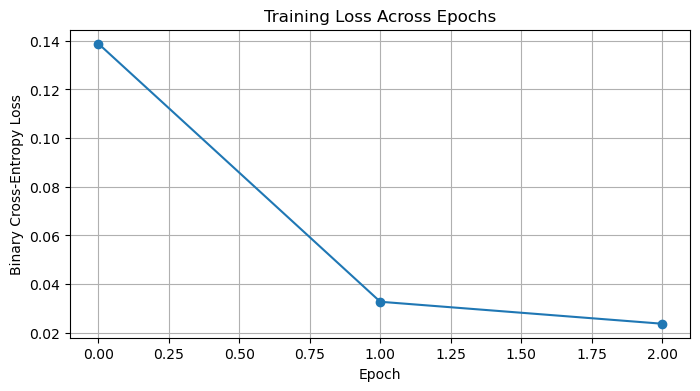

In [57]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], marker='o')
plt.title('Training Loss Across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True)
plt.show()

# Phase 6: Embedding Inspection and Diagnostics

In [ ]:
embeddings = w2v_model.get_layer('target_embedding').get_weights()[0]
print('Embedding matrix shape:', embeddings.shape)

token_to_index = {token: idx for idx, token in enumerate(vocab)}

def nearest_neighbors(word, top_k=NEIGHBOR_TOP_K):
    # top_k is a diagnostics parameter: increase for broader inspection, decrease for quick checks.
    if word not in token_to_index:
        return []

    idx = token_to_index[word]
    query = embeddings[idx]

    norms = np.linalg.norm(embeddings, axis=1) + 1e-12
    query_norm = np.linalg.norm(query) + 1e-12
    sims = np.dot(embeddings, query) / (norms * query_norm)

    best = np.argsort(-sims)
    neighbors = []
    for i in best:
        token = vocab[i]
        if token in {'', '[UNK]'} or token == word:
            continue
        neighbors.append((token, float(sims[i])))
        if len(neighbors) >= top_k:
            break
    return neighbors

# Probe tokens aligned with target_labels: DATE, FULL_NAME, EMAIL, USERNAME, STREET_ADDRESS.
# We can change this list to inspect semantic neighborhoods for any domain terms of interest.
probe_words = PROBE_WORDS
for w in probe_words:
    print(f'\nNearest neighbors for {w}:')
    print(nearest_neighbors(w))

Embedding matrix shape: (20000, 128)

Nearest neighbors for date:
[(np.str_('of'), 0.920813262462616), (np.str_('mm'), 0.9195308685302734), (np.str_('brigitte'), 0.9072613716125488), (np.str_('1993'), 0.9066872000694275), (np.str_('1975'), 0.9054408073425293), (np.str_('friday'), 0.8937392234802246), (np.str_('1933'), 0.8903765082359314), (np.str_('applicant'), 0.8897038102149963)]

Nearest neighbors for name:
[(np.str_('orlando'), 0.9276096820831299), (np.str_('julie'), 0.9266746044158936), (np.str_('artemio'), 0.903419554233551), (np.str_('tycho'), 0.9020560383796692), (np.str_('tradeheader'), 0.8971993327140808), (np.str_('henri'), 0.8918539881706238), (np.str_('language'), 0.8905919790267944), (np.str_('isa'), 0.8896608352661133)]

Nearest neighbors for email:
[(np.str_('myers'), 0.9296726584434509), (np.str_('gruppo'), 0.9236799478530884), (np.str_('metrics'), 0.9230776429176331), (np.str_('get'), 0.9229365587234497), (np.str_('important'), 0.9222143292427063), (np.str_('student')

# Phase 7: Timing and Practical Constraints

In [59]:
timing_summary = pd.DataFrame({
    'stage': ['vectorizer_adapt', 'skipgram_pair_generation', f'training_{EPOCHS}_epochs'],
    'seconds': [tokenize_adapt_seconds, pair_generation_seconds, train_seconds]
})
timing_summary['milliseconds'] = timing_summary['seconds'] * 1000
timing_summary

,stage,seconds,milliseconds
0,vectorizer_adapt,2.872179,2872.1793
1,skipgram_pair_generation,9.098165,9098.1655
2,training_3_epochs,427.522780,427522.7800
